In [5]:
import scanpy as sc
adata = sc.read("/mnt/SATA/singleCellTaru/data/adata_harmony.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 34931 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'library_id', 'controles', 'classificacao', 'estimulo', 'total_counts_rps', 'log1p_total_counts_rps', 'pct_counts_rps', 'total_counts_rpl', 'log1p_total_counts_rpl', 'pct_counts_rpl', 'leiden'
    var: 'gene_ids', 'gene_symbol', 'mt', 'rps', 'rpl', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'leiden', 'leiden_colors', 'library_id_colors', 'neighbors', 'pca', 'pearson_residuals_normalization', 'predicted_doublet_co

In [7]:
import numpy as np

resolutions = np.arange(0.1, 1, 0.1).round(1)

# Run leiden clustering for different resolutions
for resolution in resolutions:
    sc.tl.leiden(
        adata,
        resolution=resolution,
        flavor="igraph",
        key_added=f"leiden_{str(resolution).replace('.', '_')}",
    )

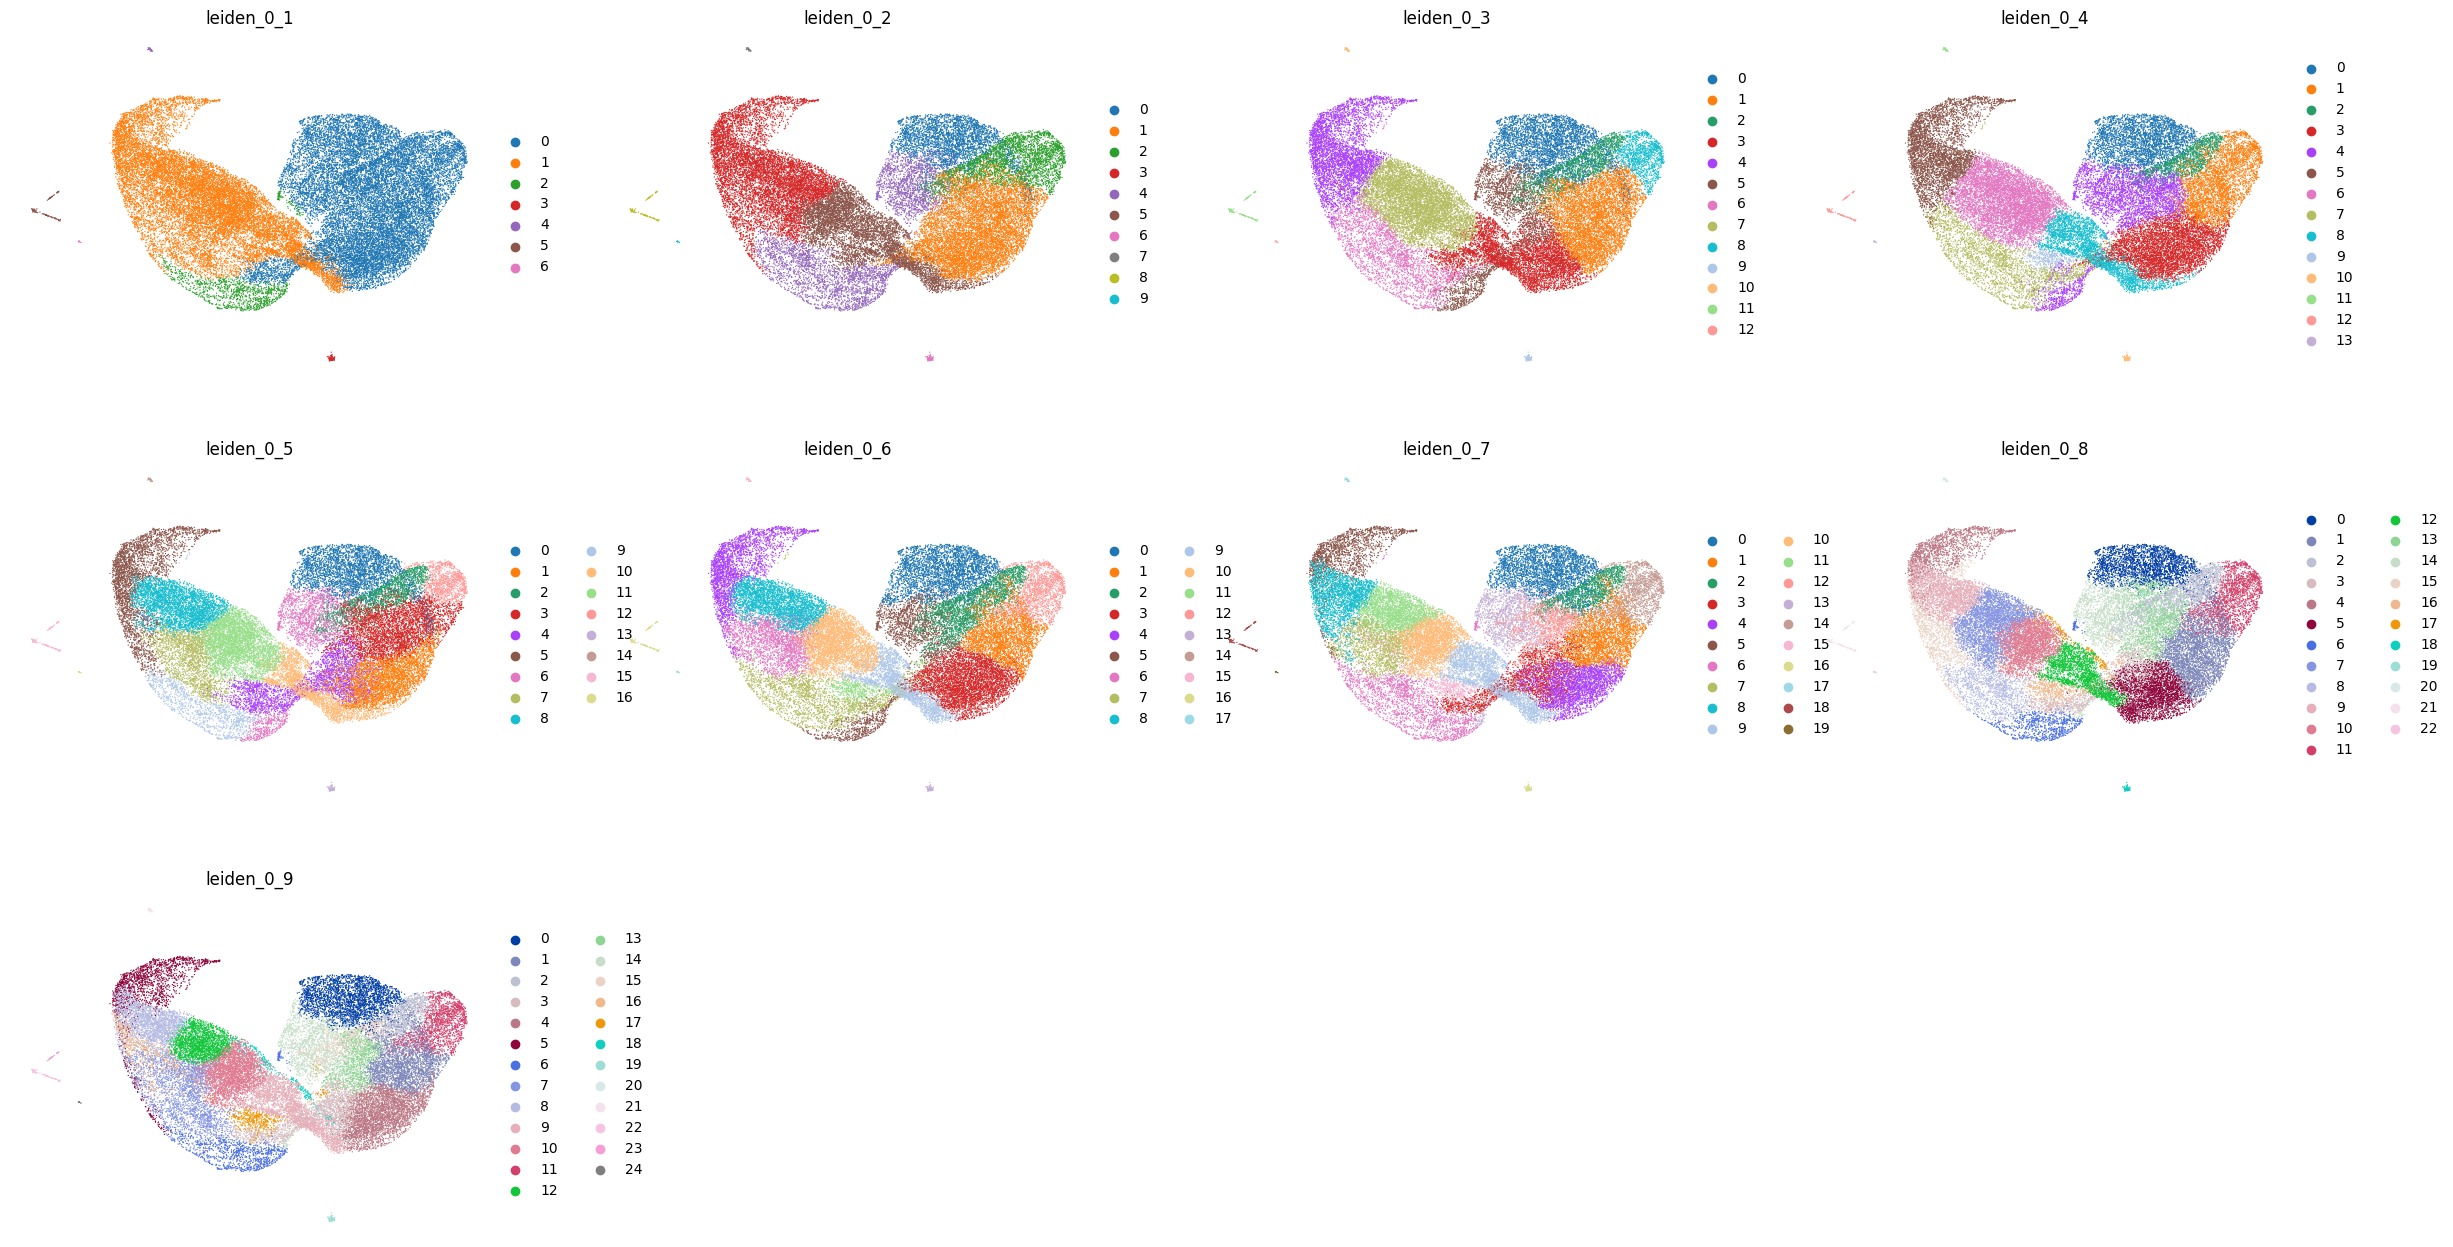

In [8]:
sc.pl.umap(
    adata,
    color=[f"leiden_{str(resolution).replace('.', '_')}" for resolution in resolutions],
    frameon=False
)

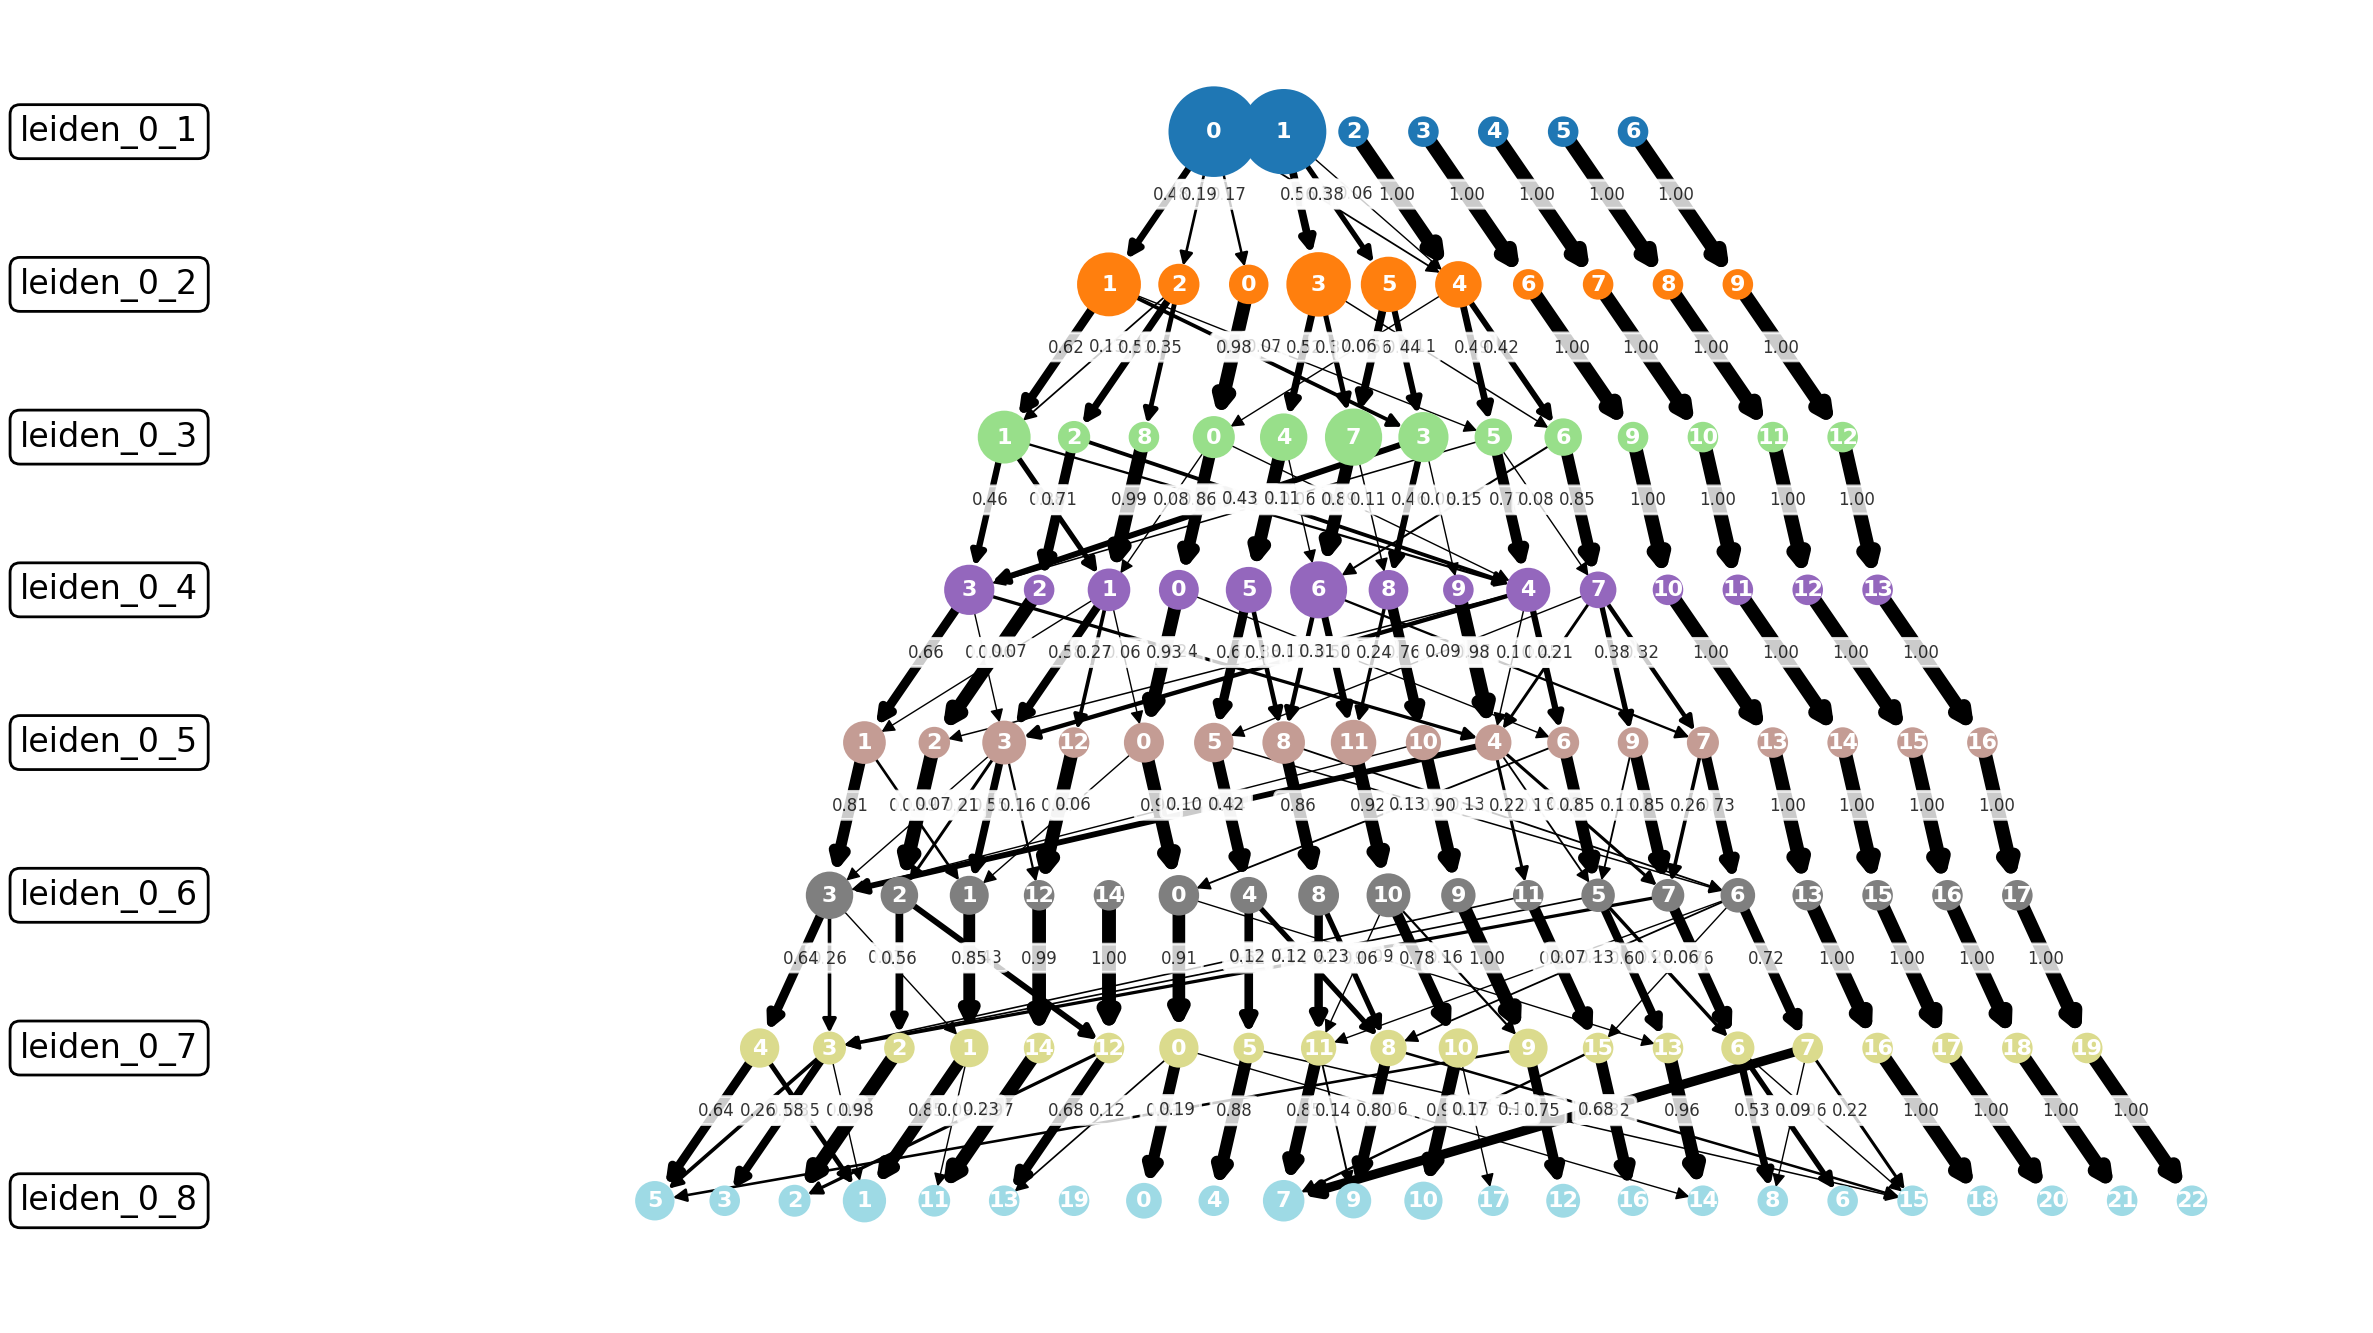

In [15]:
from pyclustree import clustree
import numpy as np

resolutions = np.arange(0.1, 0.9, 0.1).round(1)

fig = clustree(
    adata,
    [f"leiden_{str(resolution).replace('.', '_')}" for resolution in resolutions],
    title="",
    edge_weight_threshold=0.05,  # the minimum fraction of the parent cluster assigned to the child cluster to plot
    show_fraction=True,  # show the fraction of cells in each cluster
    y_spacing=1.2,  # vertical spacing between clusters
    x_spacing=1.5,  # horizontal spacing between clusters
    show_colorbar=False
)
fig.set_dpi(200)


Iniciando a busca de resolução nível publicação...


/tmp/ipykernel_59764/2112799792.py:198: UserWarning: No resolution achieved ARI ≥ 0.9. Max ARI = 0.609. Consider revising k-NN graph or increasing n_iterations in Leiden.
  warnings.warn(



🚀 A melhor resolução encontrada foi: 0.2


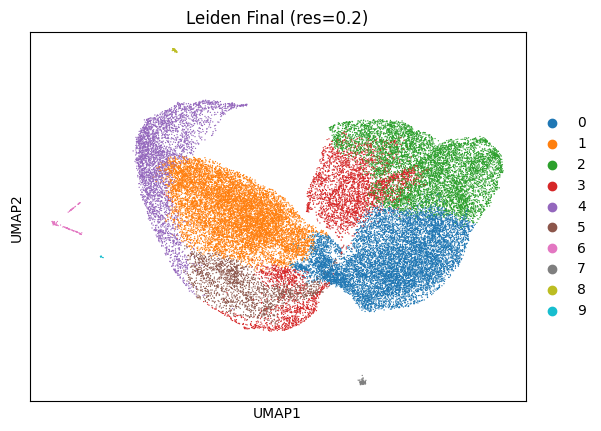

In [20]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import (adjusted_rand_score, silhouette_score,
                             davies_bouldin_score, calinski_harabasz_score)
from itertools import combinations
import warnings

class OptmalResolution():

    @staticmethod
    def _stratified_subsample(labels, subsample, random_state=0):
        """
        Retorna índices de um subsample estratificado por cluster.

        Garante que cada cluster tenha pelo menos min(cells_in_cluster, floor)
        células representadas, evitando que clusters raros desapareçam na amostra.
        A proporção de cada cluster no subsample reflete a proporção original.

        Parâmetros
        ----------
        labels : np.ndarray
            Array de labels de cluster para cada célula.
        subsample : int
            Número total de células a amostrar.
        random_state : int
            Semente para reprodutibilidade.

        Retorna
        -------
        np.ndarray
            Índices das células selecionadas.
        """
        rng = np.random.default_rng(random_state)
        unique_labels, counts = np.unique(labels, return_counts=True)
        n_total = len(labels)

        # mínimo de células por cluster: pelo menos 1, ou proporcional ao subsample
        min_per_cluster = max(1, subsample // (10 * len(unique_labels)))

        selected = []
        remaining_budget = subsample

        # primeira passagem: garantir mínimo por cluster
        cluster_indices = {}
        for lbl in unique_labels:
            cluster_indices[lbl] = np.where(labels == lbl)[0]

        guaranteed = {}
        for lbl in unique_labels:
            idxs = cluster_indices[lbl]
            n_guarantee = min(min_per_cluster, len(idxs))
            chosen = rng.choice(idxs, size=n_guarantee, replace=False)
            guaranteed[lbl] = set(chosen.tolist())
            selected.extend(chosen.tolist())

        remaining_budget -= len(selected)

        if remaining_budget > 0:
            # segunda passagem: distribuir o restante proporcionalmente
            proportions = counts / n_total
            extra_per_cluster = np.floor(proportions * remaining_budget).astype(int)

            for lbl, n_extra in zip(unique_labels, extra_per_cluster):
                if n_extra <= 0:
                    continue
                idxs = cluster_indices[lbl]
                # excluir os já selecionados
                available = np.array([i for i in idxs if i not in guaranteed[lbl]])
                if len(available) == 0:
                    continue
                n_sample = min(n_extra, len(available))
                chosen = rng.choice(available, size=n_sample, replace=False)
                selected.extend(chosen.tolist())

        return np.array(selected[:subsample])

    @staticmethod
    def _minmax_norm(arr):
        arr = np.asarray(arr, dtype=float)
        lo, hi = np.nanmin(arr), np.nanmax(arr)
        if hi == lo:
            return np.zeros_like(arr)
        return (arr - lo) / (hi - lo)

    @staticmethod
    def _compute_gini(labels):
        counts = np.sort(np.unique(labels, return_counts=True)[1])
        n = len(counts)
        if n == 0:
            return np.nan
        gini = (2 * np.sum(np.arange(1, n+1) * counts) / (n * counts.sum())) - (n+1)/n
        return gini

    @staticmethod
    def select_leiden_resolution_publication(
        adata,
        resolutions_coarse=None,
        use_rep="X_scVI",
        n_stability_runs=20,          # ARI stability runs per resolution
        n_silhouette_boots=10,        # bootstrap iterations for silhouette CI
        subsample=5000,
        min_ari_threshold=0.90,       # Skinnider et al. criterion
        random_state=42,
    ):
        """
        Publication-grade resolution selection for Leiden clustering.
        
        Algorithm:
        ----------
        1. Coarse sweep: compute ARI stability + composite quality for each resolution
        2. Filter to stable resolutions (mean ARI ≥ threshold)
        3. Among stable: select by composite quality score (Sil + DB + CH)
        4. Fine sweep: ±1 coarse step around winner, step/5 granularity
        5. Repeat steps 1-3 on fine grid
        6. Return best resolution with full diagnostics
        
        Returns
        -------
        dict with keys: best_resolution, stability_table, quality_table, 
                        fine_grid_result, diagnostics
        """
        if resolutions_coarse is None:
            resolutions_coarse = np.round(np.arange(0.1, 2.1, 0.1), 2)
        
        X = adata.obsm[use_rep]
        
        results = {}
        
        for res in resolutions_coarse:
            # --- ARI stability ---
            partitions = []
            for seed in range(random_state, random_state + n_stability_runs):
                key = f"_tmp_{res}_{seed}"
                sc.tl.leiden(adata, resolution=float(res), key_added=key, 
                            random_state=seed)
                partitions.append(adata.obs[key].astype(str).values.copy())
                del adata.obs[key]
            
            aris = [adjusted_rand_score(partitions[i], partitions[j])
                    for i, j in combinations(range(n_stability_runs), 2)]
            
            n_clusters_per_run = [len(np.unique(p)) for p in partitions]
            
            # --- Quality metrics (on consensus: most common partition) ---
            # Use the first run's partition as representative
            labels = partitions[0]
            
            # Stratified subsample
            sil_scores = []
            for boot in range(n_silhouette_boots):
                idx = OptmalResolution._stratified_subsample(labels, subsample, 
                                            random_state=random_state + boot)
                if len(np.unique(labels[idx])) < 2:
                    continue
                s = silhouette_score(X[idx], labels[idx], metric='cosine')
                sil_scores.append(s)
            
            # DB and CH on full data (or subsample for large datasets)
            if len(np.unique(labels)) >= 2:
                db  = davies_bouldin_score(X, labels)
                ch  = calinski_harabasz_score(X, labels)
            else:
                db, ch = np.nan, np.nan
            
            results[res] = {
                "mean_ari":        np.mean(aris),
                "sd_ari":          np.std(aris),
                "n_clusters_mean": np.mean(n_clusters_per_run),
                "n_clusters_sd":   np.std(n_clusters_per_run),
                "sil_mean":        np.mean(sil_scores) if sil_scores else np.nan,
                "sil_sd":          np.std(sil_scores) if sil_scores else np.nan,
                "davies_bouldin":  db,
                "calinski_harabasz": ch,
                "gini":            OptmalResolution._compute_gini(labels),
            }
        
        # --- Composite score (normalized) ---
        sil_vals = np.array([results[r]["sil_mean"] for r in resolutions_coarse])
        db_vals  = np.array([results[r]["davies_bouldin"] for r in resolutions_coarse])
        ch_vals  = np.array([results[r]["calinski_harabasz"] for r in resolutions_coarse])
        
        sil_norm = OptmalResolution._minmax_norm(sil_vals)
        db_norm  = OptmalResolution._minmax_norm(1 / (1 + db_vals))   # invert DB
        ch_norm  = OptmalResolution._minmax_norm(np.log1p(ch_vals))
        
        composite = (sil_norm + db_norm + ch_norm) / 3.0
        
        for i, res in enumerate(resolutions_coarse):
            results[res]["composite_score"] = composite[i]
        
        # --- Filter stable + select best ---
        stable = [r for r in resolutions_coarse 
                if results[r]["mean_ari"] >= min_ari_threshold]
        
        if not stable:
            warnings.warn(
                f"No resolution achieved ARI ≥ {min_ari_threshold}. "
                f"Max ARI = {max(results[r]['mean_ari'] for r in resolutions_coarse):.3f}. "
                f"Consider revising k-NN graph or increasing n_iterations in Leiden."
            )
            stable = sorted(resolutions_coarse,
                        key=lambda r: results[r]["mean_ari"], reverse=True)[:3]
        
        best_coarse = max(stable, key=lambda r: results[r]["composite_score"])
        
        return {
            "best_resolution": best_coarse,
            "all_results": results,
            "stable_resolutions": stable,
            "composite_scores": {r: results[r]["composite_score"] 
                                for r in resolutions_coarse},
        }

# 1. Supondo que você já carregou seu adata e rodou o scVI

# 2. Definir a grade de resoluções que você quer testar (opcional)
grades_resolucao = np.round(np.arange(0.2, 0.8, 0.1), 2)

# 3. Executar o selecionador estatístico
print("Iniciando a busca de resolução nível publicação...")
resultado_pipeline = OptmalResolution.select_leiden_resolution_publication(
    adata=adata,
    resolutions_coarse=grades_resolucao,
    use_rep="X_emb_harmony",
    n_stability_runs=3,       # Quantas vezes o Leiden rodará por resolução para medir estabilidade (ARI)
    n_silhouette_boots=5,     # Repetições da amostragem estratificada para a silhueta
    subsample=2000,            # Tamanho da subamostra para cálculo da silhueta
    min_ari_threshold=0.90,    # Rigor de estabilidade (padrão Skinnider et al.)
    random_state=42
)

# 4. Extrair e aplicar a melhor resolução encontrada
melhor_res = resultado_pipeline["best_resolution"]
print(f"\n🚀 A melhor resolução encontrada foi: {melhor_res}")

# Agora você aplica ela definitivamente no seu adata
sc.tl.leiden(adata, resolution=melhor_res, key_added="leiden_final")

# 5. Visualizar o resultado no UMAP
sc.pl.umap(adata, color="leiden_final", title=f"Leiden Final (res={melhor_res})")

In [21]:
adata.write_h5ad("/mnt/SATA/singleCellTaru/data/adata_harmony.h5ad")